In [1]:
import sys
import os
import json
sys.path.append(os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

#import preprocessing functions
from src.preprocessing import preprocess

#import XGBoost specific functions
from src.XGBoost import train_XGBoost, test_XGBoost

In [3]:
# -- Load Training and Testing Dataframes
clean_train = pd.read_csv('../data/clean/clean_train.csv',index_col=0,low_memory=False)
clean_test = pd.read_csv('../data/clean/clean_test.csv',index_col=0,low_memory=False)

In [4]:
# --Defining targets and model/scores dictionaries
training_features = ['MolWt', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'LogP'] + \
                    [col for col in clean_train.columns if col.startswith('fps_')]
targets = []
for col in clean_train.columns:
    if col in training_features:
        continue
    elif 'fps' in col: 
        continue
    elif col.startswith('log_'):
        targets.append(col)
    elif clean_train[col].dtype in ['float64', 'int64']:
        # Only add raw column if no log version exists
        log_version = f'log_{col}'
        if log_version not in clean_train.columns:
            targets.append(col)
            
xgb_models = {}
xgb_scores = {}
xgb_data = {}

#### Load Trained Models into dictionary, since XGBoost models were trained using External Resources

In [21]:
import joblib
import os

xgb_models = {}

model_dir = '../models/XGBoost'
for filename in os.listdir(model_dir):
    if filename.endswith('.pkl'):
        target = filename.replace('xgb_', '').replace('.pkl', '')
        xgb_models[target] = joblib.load(os.path.join(model_dir, filename))


with open('../models/XGBoost/xgb_scores.json', 'r') as f:
    xgb_scores = {target: np.array(scores) for target, scores in json.load(f).items()}

xgb_data = {}
for target in xgb_scores.keys():
    y = np.load(f'../models/XGBoost/y_{target}.npy', allow_pickle=True)
    y_pred_cv = np.load(f'../models/XGBoost/y_pred_cv_{target}.npy', allow_pickle=True)
    xgb_data[target] = (None, y, y_pred_cv)

/usr/lib/python3.10/pickle.py:1718: UserWarning: [13:06:50] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


In [ ]:
# -- Training
for target in targets:
    model, scores, X, y, y_pred_cv = train_xgboost(clean_train, target)
    xgb_models[target] = model
    xgb_scores[target] = scores
    xgb_data[target] = (X, y, y_pred_cv)

#### Output the importance of each feature to the prediction -- higher number means more useful for predictions

In [22]:
for target, model in xgb_models.items():
    print(f"\n--- Summary for: {target} ---")
    
    summary_df = pd.DataFrame({
        'Feature': model.feature_names_in_,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)
    
    print(summary_df.to_string(index=False))
    
    mean_score = xgb_scores[target].mean()
    print(f"Mean CV R2: {mean_score:.4f}")


--- Summary for: log_MLM CLint ---
Feature  Importance
fps_486    0.102042
fps_488    0.070839
fps_563    0.022629
fps_533    0.021300
fps_721    0.014355
 fps_64    0.012018
fps_334    0.011567
fps_628    0.011111
fps_579    0.011005
fps_387    0.009853
 fps_77    0.008580
fps_741    0.007925
fps_808    0.007504
fps_558    0.007210
fps_560    0.006773
Mean CV R2: 0.1724

--- Summary for: KSOL ---
 Feature  Importance
 fps_659    0.058646
 fps_736    0.046264
 fps_197    0.027543
 fps_904    0.023916
  fps_60    0.020155
 fps_386    0.017561
 fps_598    0.017437
 fps_593    0.017061
  fps_13    0.016996
 fps_684    0.014642
 fps_631    0.014217
fps_1003    0.013721
 fps_407    0.013033
 fps_926    0.011283
 fps_614    0.010154
Mean CV R2: 0.0560

--- Summary for: LogD ---
 Feature  Importance
 fps_659    0.052732
 fps_702    0.030151
 fps_902    0.028210
 fps_665    0.026390
 fps_197    0.026178
 fps_162    0.022416
 fps_561    0.021401
 fps_961    0.015942
fps_1023    0.015207
 fps_4

#### Plot 10-Fold CV R2 scores

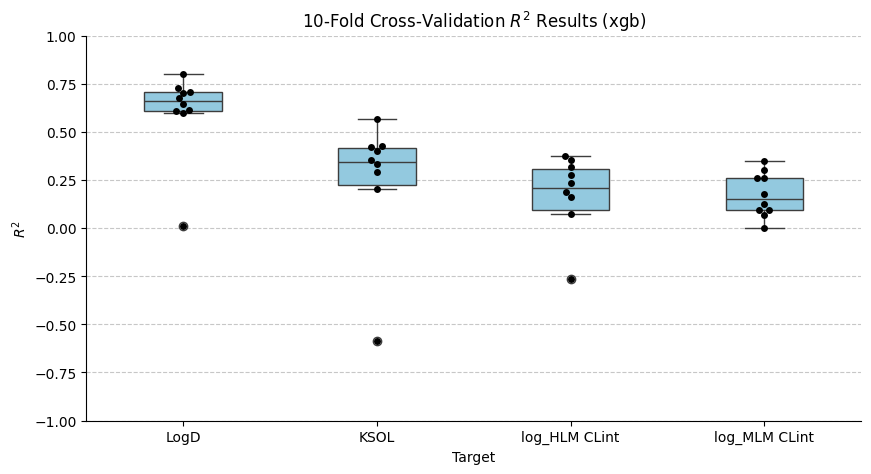

In [23]:
scores_df_xgb = pd.DataFrame(xgb_scores)

plt.figure(figsize=(10, 5))
sns.boxplot(data=scores_df_xgb, color='skyblue', width=0.4)
sns.swarmplot(data=scores_df_xgb, color='black')

plt.title(r'10-Fold Cross-Validation $R^2$ Results (xgb)')
plt.ylabel(r'$R^2$')
plt.ylim(-1,1)
plt.xlabel('Target')
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()
plt.show()

#### Plot the residuals to check for any correlations -- ideally there should be none

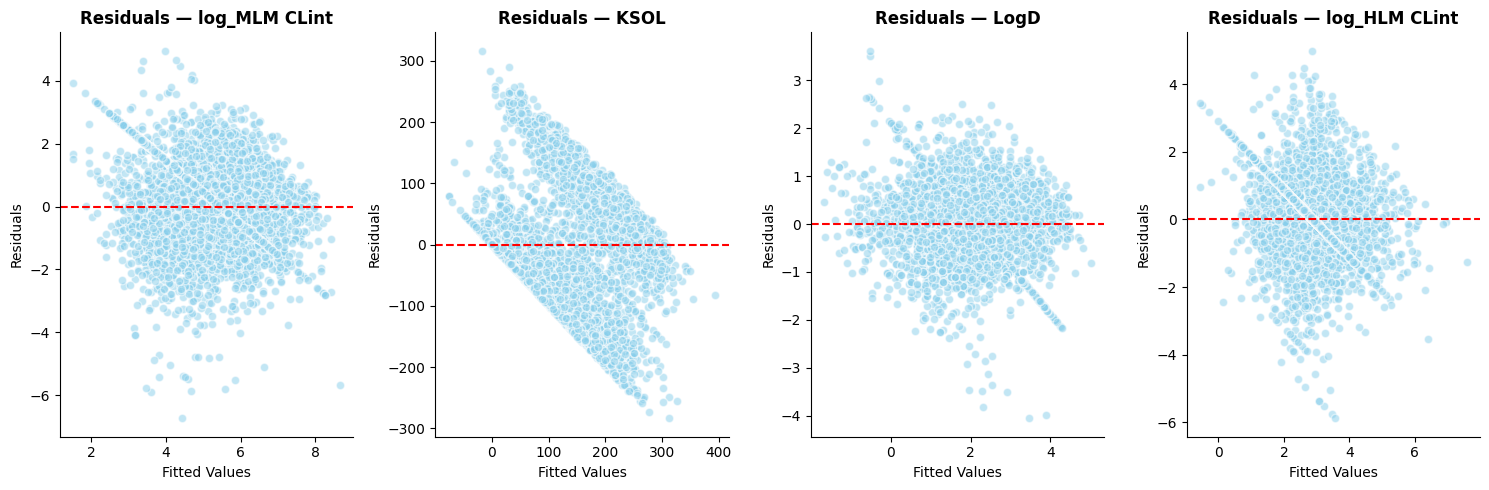

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, (target, model) in zip(axes, xgb_models.items()):
    X, y, y_pred_cv = xgb_data[target]
    residuals = y - y_pred_cv
    ax.scatter(y_pred_cv, residuals, alpha=0.5, color='skyblue', edgecolors='white')
    ax.axhline(y=0, color='red', linestyle='--')
    ax.set_title(f'Residuals — {target}', fontweight='bold')
    ax.set_xlabel('Fitted Values')
    ax.set_ylabel('Residuals')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

In [26]:
xgb_pred = {} #dictionary to hold the predictions from each model
xgb_resid = {} #dictionary to hold the residuals for later convience
for target in xgb_models.keys():
    #predict each target using its respective trained lasso regression model and store results in the xgb_pred dictionary
    xgb_pred[target] = test_XGBoost(clean_test,xgb_models[target])

    residuals = xgb_pred[target] - clean_test[target] #calcualte residuals
    xgb_resid[target] = residuals #store resids

log_MLM CLint | $R^2 = 0.633$
############################################################
log_MLM CLint Evaluation Table
        MSE      RMSE       MAE        R2
0  0.689931  0.830621  0.597435  0.632722
KSOL | $R^2 = 0.665$
############################################################
KSOL Evaluation Table
           MSE       RMSE        MAE        R2
0  4451.168255  66.717076  46.671112  0.664586
LogD | $R^2 = 0.837$
############################################################
LogD Evaluation Table
        MSE      RMSE       MAE        R2
0  0.208692  0.456828  0.287965  0.836505
log_HLM CLint | $R^2 = 0.668$
############################################################
log_HLM CLint Evaluation Table
        MSE      RMSE       MAE        R2
0  0.415124  0.644301  0.454648  0.668295


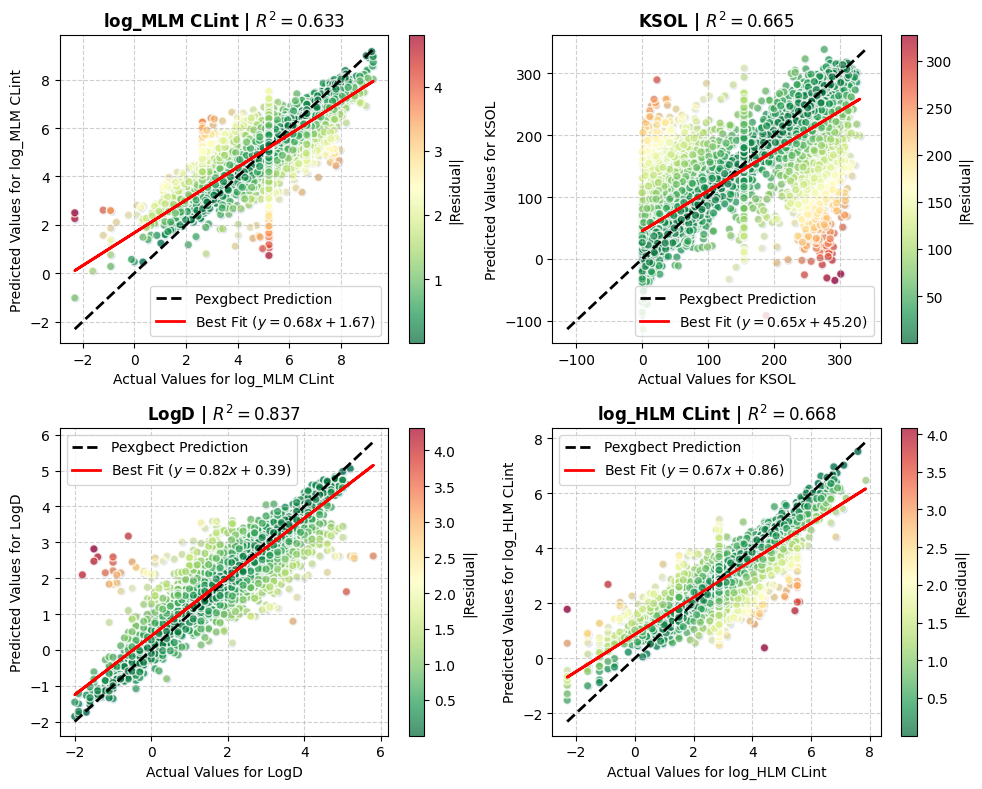

In [27]:
from src.evaluate import eval_model

# Plot test results for each Lasso model
fig, axs = plt.subplots(2, 2, figsize=(10, 8)) #Set axis
axs_flat = axs.flatten()  #flatten to use in loop

for i, target in enumerate(xgb_pred.keys()):
    ax = axs_flat[i]
    y_pred = xgb_pred[target]
    y_real = clean_test[target]
    mse, rmse, mae, r2 = eval_model(y_real, y_pred) #calculate evaluation metrics
    m, b = np.polyfit(y_real, y_pred, 1)
    ax.scatter(y_real, y_pred, alpha=0.5, color='royalblue', edgecolors='w')
    residuals = abs(xgb_resid[target])
    scatter = ax.scatter(y_real, y_pred, c=residuals, cmap='RdYlGn_r', #colour the residuals based on proximity to pexgbect prediction
                     alpha=0.7, edgecolors='w')
    plt.colorbar(scatter, ax=ax, label='|Residual|')
    min_val = min(min(y_real), min(y_pred))
    max_val = max(max(y_real), max(y_pred))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Pexgbect Prediction') #line representing pexgbect prediction
    ax.plot(y_real, m * y_real + b, color='red', lw=2, label=f'Best Fit ($y={m:.2f}x{b:+.2f}$)') #line of best fit

    ax.set_xlabel(f'Actual Values for {target}')
    ax.set_ylabel(f'Predicted Values for {target}')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()
    ax.set_title(f'{target} | $R^2 = {r2:.3f}$', fontsize=12, fontweight='bold')

    print(f'{target} | $R^2 = {r2:.3f}$')

    ##########Build Evaluation Table###########
    evaluation_results = {'MSE' : mse,
                          'RMSE': rmse,
                          'MAE' : mae,
                          'R2'  : r2 }
    eval_table = pd.DataFrame(evaluation_results,index=[0])
    print('#'*60)
    print(f'{target} Evaluation Table')
    print(eval_table)

plt.tight_layout()
plt.show()